# EEGNet Preprocessing + BERT Retrieval — Laslo Tudor Alexandru (P1)
## Saptamana 14 — Proiect EEG-to-Text

**Branch:** `Sapt_14_Laslo` | **PR #2**

Pipeline: fișiere per-subiect ZuCo1 SR -> preprocesare -> EEGNet (128d) -> proiectie liniara -> BERT retrieval (200 cuvinte)


## 0. Setup director de lucru

In [1]:
import os
from pathlib import Path

# Schimba directorul la radacina repo-ului
search = Path.cwd()
for _ in range(6):
    if (search / 'benchmark_config.json').exists():
        os.chdir(search)
        break
    search = search.parent

print('Working directory:', os.getcwd())
assert Path('benchmark_config.json').exists(), 'benchmark_config.json nu gasit!'
print('benchmark_config.json: OK')


Working directory: C:\Users\alexl\School\AI\eeg_ai_project\EEG-text
benchmark_config.json: OK


## 1. Incarcare date
Incarcam cele 5 fisiere per-subiect din folderul ZuCo1 SR si `benchmark_config.json`.
Structura: `sentenceData` -> lista de propozitii -> `word` -> `rawEEG` shape (4, 105, 120).
Concatenam cele 4 ferestre temporale -> (105, 480), pad la 500 samples.

In [2]:
import scipy.io as sio
import numpy as np
import json
import glob

# Folderul cu fisierele per-subiect
EEG_DIR     = r'C:\Users\alexl\School\AI\eeg_ai_project\project\data\ZuCo1\task1_SR'
CONFIG_PATH = 'benchmark_config.json'

mat_files = sorted(glob.glob(os.path.join(EEG_DIR, 'results*_SR.mat')))
print(f'Fisiere gasite: {len(mat_files)}')
for f in mat_files:
    print(' ', os.path.basename(f))

with open(CONFIG_PATH) as f:
    config = json.load(f)

print(f"\nVocabular: {len(config['vocabulary'])} cuvinte")
print(f"Split: train={len(config['train_words'])}, val={len(config['val_words'])}, test={len(config['test_words'])}")
print(f"EEG config: {config['eeg']}")


Fisiere gasite: 5
  resultsZAB_SR.mat
  resultsZDM_SR.mat
  resultsZDN_SR.mat
  resultsZJS_SR.mat
  resultsZKB_SR.mat

Vocabular: 200 cuvinte
Split: train=140, val=30, test=30
EEG config: {'n_channels': 105, 'sampling_rate_hz': 500, 'epoch_window_ms': [-200, 800], 'baseline_ms': [-200, 0]}


## 2. Extragere epoci EEG per cuvant
Iteram prin toate fisierele per-subiect si toate propozitiile.
rawEEG shape (4, 105, 120) -> concatenat -> (105, 480) -> pad/crop la 500 samples.

In [3]:
VOCABULARY  = set(config['vocabulary'])
TRAIN_WORDS = set(config['train_words'])
VAL_WORDS   = set(config['val_words'])
TEST_WORDS  = set(config['test_words'])
N_CHANNELS  = config['eeg']['n_channels']       # 105
FS          = config['eeg']['sampling_rate_hz'] # 500
START_MS    = config['eeg']['epoch_window_ms'][0]
END_MS      = config['eeg']['epoch_window_ms'][1]
T_SAMPLES   = int((END_MS - START_MS) / 1000 * FS)  # 500
BASELINE_S  = int(abs(START_MS) / 1000 * FS)        # 100

epochs_list, labels_list, split_list, subj_list = [], [], [], []
skipped_no_vocab, skipped_shape, skipped_err = 0, 0, 0

for mat_path in mat_files:
    subj_name = os.path.basename(mat_path).replace('results','').replace('_SR.mat','')
    try:
        mat = sio.loadmat(mat_path, simplify_cells=True)
    except Exception as e:
        print(f'Eroare la {subj_name}: {e}')
        continue

    sentence_data = mat['sentenceData']
    print(f'{subj_name}: {len(sentence_data)} propozitii')

    for sentence in sentence_data:
        try:
            words = sentence['word']
        except (KeyError, TypeError):
            continue
        if not hasattr(words, '__len__'):
            words = [words]

        for word_obj in words:
            try:
                word_text = str(word_obj['content']).lower().strip()
                raw_eeg   = word_obj['rawEEG']  # shape (4, 105, 120)
            except (KeyError, TypeError):
                skipped_err += 1
                continue

            if word_text not in VOCABULARY:
                skipped_no_vocab += 1
                continue

            if not hasattr(raw_eeg, 'ndim'):
                raw_eeg = np.array(raw_eeg)

            # Concatenam cele 4 ferestre temporale: (4, 105, 120) -> (105, 480)
            if raw_eeg.ndim == 3 and raw_eeg.shape[1] == N_CHANNELS:
                # shape (4, 105, 120) -> transpose -> (105, 4*120)
                epoch = raw_eeg.transpose(1, 0, 2).reshape(N_CHANNELS, -1)
            elif raw_eeg.ndim == 2 and raw_eeg.shape[0] == N_CHANNELS:
                epoch = raw_eeg
            else:
                skipped_shape += 1
                continue

            # Pad sau crop la T_SAMPLES (500)
            T = epoch.shape[1]
            if T < T_SAMPLES:
                epoch = np.hstack([epoch, np.zeros((N_CHANNELS, T_SAMPLES - T))])
            else:
                epoch = epoch[:, :T_SAMPLES]

            # Split
            if word_text in TRAIN_WORDS:   split = 'train'
            elif word_text in VAL_WORDS:   split = 'val'
            elif word_text in TEST_WORDS:  split = 'test'
            else: continue

            epochs_list.append(epoch.astype(np.float32))
            labels_list.append(word_text)
            split_list.append(split)
            subj_list.append(subj_name)

print(f'\nTotal epoci: {len(epochs_list)}')
print(f'Train: {split_list.count("train")}, Val: {split_list.count("val")}, Test: {split_list.count("test")}')
print(f'Cuvinte unice: {len(set(labels_list))}')
print(f'Sarite (nu in vocab): {skipped_no_vocab}, shape gresita: {skipped_shape}, erori: {skipped_err}')


ZAB: 400 propozitii
ZDM: 400 propozitii
ZDN: 400 propozitii
ZJS: 400 propozitii
ZKB: 400 propozitii

Total epoci: 1136
Train: 922, Val: 106, Test: 108
Cuvinte unice: 85
Sarite (nu in vocab): 31386, shape gresita: 1271, erori: 117


## 3. Preprocesare EEG
1. Bandpass 0.5-40 Hz (Butterworth IIR ord 4)
2. Baseline correction (primele 100 samples = 200ms pre-stimulus)
3. Artifact rejection (prag 100 uV)
4. Z-score per canal

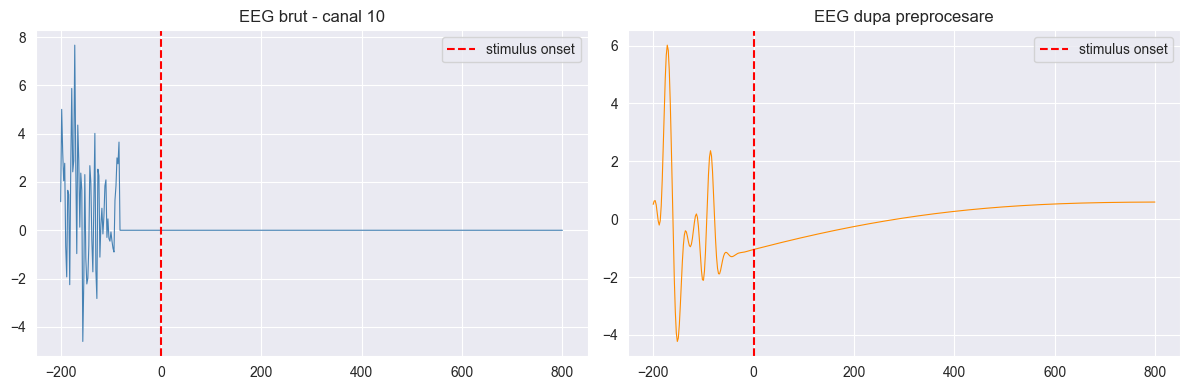

Dupa preprocesare: (1136, 105, 500), respinse (artefacte): 0
Train: 922, Val: 106, Test: 108
Salvate: data/X_preprocessed.npy, y_labels.npy, splits.npy


In [4]:
import mne
from mne import create_info
import matplotlib.pyplot as plt

def preprocess_epoch(eeg, fs=500, l_freq=0.5, h_freq=40.0, baseline_s=100, thresh=100.0):
    info = create_info(ch_names=eeg.shape[0], sfreq=fs, ch_types='eeg')
    raw  = mne.io.RawArray(eeg, info, verbose=False)
    raw.filter(l_freq=l_freq, h_freq=h_freq, method='iir',
               iir_params={'order': 4, 'ftype': 'butter'}, verbose=False)
    f = raw.get_data()
    c = f - f[:, :baseline_s].mean(axis=1, keepdims=True)
    if np.any(np.abs(c) > thresh):
        return None
    return ((c - c.mean(axis=1, keepdims=True)) / (c.std(axis=1, keepdims=True) + 1e-8)).astype(np.float32)

# Grafic ERP inainte/dupa
times = np.linspace(START_MS, END_MS, T_SAMPLES)
if epochs_list:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(times, epochs_list[0][10], color='steelblue', lw=0.8)
    ax[0].axvline(0, color='red', ls='--', label='stimulus onset')
    ax[0].set_title('EEG brut - canal 10'); ax[0].legend()
    p = preprocess_epoch(epochs_list[0])
    if p is not None:
        ax[1].plot(times, p[10], color='darkorange', lw=0.8)
        ax[1].axvline(0, color='red', ls='--', label='stimulus onset')
        ax[1].set_title('EEG dupa preprocesare'); ax[1].legend()
    plt.tight_layout()
    plt.savefig('notebooks/Laslo/erp_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()

processed_epochs, processed_labels, processed_splits, rejected = [], [], [], 0
for eeg, label, split in zip(epochs_list, labels_list, split_list):
    r = preprocess_epoch(eeg)
    if r is not None:
        processed_epochs.append(r)
        processed_labels.append(label)
        processed_splits.append(split)
    else:
        rejected += 1

X      = np.array(processed_epochs)
y      = np.array(processed_labels)
splits = np.array(processed_splits)

print(f'Dupa preprocesare: {X.shape}, respinse (artefacte): {rejected}')
print(f'Train: {(splits=="train").sum()}, Val: {(splits=="val").sum()}, Test: {(splits=="test").sum()}')
np.save('data/X_preprocessed.npy', X)
np.save('data/y_labels.npy', y)
np.save('data/splits.npy', splits)
print('Salvate: data/X_preprocessed.npy, y_labels.npy, splits.npy')


## 4. Mapare label -> index POS
Antrenam EEGNet ca clasificator POS (sarcina proxy). Salvam `vocab_index.json` pentru Lupse.

In [5]:
from collections import Counter

vocab_list = config['vocabulary']
pos_map    = config['vocabulary_pos']
idx2word   = {i: w for i, w in enumerate(vocab_list)}

os.makedirs('app/models', exist_ok=True)
with open('app/models/vocab_index.json', 'w') as f:
    json.dump({str(i): w for i, w in idx2word.items()}, f, indent=2)
print('Salvat: app/models/vocab_index.json')

pos_labels_unique = sorted(set(pos_map.values()))
pos2idx = {p: i for i, p in enumerate(pos_labels_unique)}
print('POS classes:', pos2idx)

y_pos = np.array([pos2idx[pos_map[l]] for l in processed_labels])
train_idx = np.where(splits == 'train')[0]
val_idx   = np.where(splits == 'val')[0]
test_idx  = np.where(splits == 'test')[0]
X_train, y_train = X[train_idx], y_pos[train_idx]
X_val,   y_val   = X[val_idx],   y_pos[val_idx]
X_test,  y_test  = X[test_idx],  y_pos[test_idx]
print(f'X_train:{X_train.shape}, X_val:{X_val.shape}, X_test:{X_test.shape}')
print('Distributie POS train:', dict(Counter([pos_map[l] for l in np.array(processed_labels)[train_idx]])))


Salvat: app/models/vocab_index.json
POS classes: {'ADJ': 0, 'ADP': 1, 'ADV': 2, 'INTJ': 3, 'NOUN': 4, 'NUM': 5, 'PRON': 6, 'PROPN': 7, 'SCONJ': 8, 'VERB': 9}
X_train:(922, 105, 500), X_val:(106, 105, 500), X_test:(108, 105, 500)
Distributie POS train: {'ADJ': 163, 'VERB': 81, 'NOUN': 388, 'ADV': 88, 'NUM': 66, 'ADP': 18, 'PRON': 38, 'INTJ': 46, 'PROPN': 21, 'SCONJ': 13}


## 5. Antrenare EEGNet cu embedding layer 128 dim
Config: F1=8, D=2, F2=16, kernLength=64. Backbone + Linear(->128) + Linear(->N_CLASSES).
Incercam automat ambele variante de parametru (kernel_length vs kernLength).

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
N_CLASSES = len(pos_labels_unique)

class EEGNetWithEmbedding(nn.Module):
    """EEGNet implementat direct in PyTorch, fara braindecode.
    Input: (batch, 1, n_channels=105, n_times=500)
    """
    def __init__(self, n_channels=105, n_times=500,
                 F1=8, D=2, F2=16, kern_len=64,
                 embed_dim=128, n_cls=N_CLASSES, drop_prob=0.5):
        super().__init__()

        # Block 1: Temporal conv + Depthwise spatial conv
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_len), padding=(0, kern_len//2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(drop_prob),
        )
        # Block 2: Separable conv
        self.block2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1, 16), padding=(0, 8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(drop_prob),
        )
        # Calculeaza dim dupa convolutii
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out   = self.block2(self.block1(dummy))
            flat_dim = out.flatten(1).shape[-1]
        print(f'Flatten dim dupa conv: {flat_dim}')

        self.emb  = nn.Linear(flat_dim, embed_dim)
        self.drop = nn.Dropout(drop_prob)
        self.cls  = nn.Linear(embed_dim, n_cls)

    def forward(self, x, return_embedding=False):
        # x: (batch, 1, 105, 500)
        f = self.block2(self.block1(x)).flatten(1)
        e = self.emb(f)
        return e if return_embedding else self.cls(self.drop(e))

model = EEGNetWithEmbedding().to(device)
print(f'Parametri totali: {sum(p.numel() for p in model.parameters()):,}')

Device: cpu
Flatten dim dupa conv: 240
Parametri totali: 34,922


In [11]:
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train[:,np.newaxis,:,:], dtype=torch.float32),
                  torch.tensor(y_train, dtype=torch.long)),
    batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val[:,np.newaxis,:,:], dtype=torch.float32),
                  torch.tensor(y_val, dtype=torch.long)),
    batch_size=32)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
criterion = nn.CrossEntropyLoss()
N_EPOCHS  = 30
best_val_acc = 0.0
train_losses, val_accs = [], []

for epoch in range(N_EPOCHS):
    model.train()
    tl, tc, tt = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        tl += loss.item()*xb.size(0)
        tc += (logits.argmax(1)==yb).sum().item()
        tt += xb.size(0)
    model.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            vc += (model(xb).argmax(1)==yb).sum().item()
            vt += xb.size(0)
    el = tl/max(tt,1); va = vc/max(vt,1)
    train_losses.append(el); val_accs.append(va)
    scheduler.step()
    if (epoch+1)%5==0 or va>best_val_acc:
        print(f'Ep {epoch+1:02d}/{N_EPOCHS} | Loss:{el:.4f} | TrainAcc:{tc/max(tt,1):.3f} | ValAcc:{va:.3f}')
    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), 'app/models/eegnet_model.pt')
        print(f'  -> Model salvat (val={va:.3f})')
print('Best val acc:', round(best_val_acc, 3))


Ep 01/30 | Loss:2.0317 | TrainAcc:0.343 | ValAcc:0.453
  -> Model salvat (val=0.453)
Ep 05/30 | Loss:1.8096 | TrainAcc:0.417 | ValAcc:0.443
Ep 06/30 | Loss:1.7950 | TrainAcc:0.414 | ValAcc:0.462
  -> Model salvat (val=0.462)
Ep 10/30 | Loss:1.7615 | TrainAcc:0.412 | ValAcc:0.443
Ep 15/30 | Loss:1.7155 | TrainAcc:0.426 | ValAcc:0.434
Ep 20/30 | Loss:1.6922 | TrainAcc:0.426 | ValAcc:0.425
Ep 25/30 | Loss:1.6677 | TrainAcc:0.432 | ValAcc:0.406
Ep 30/30 | Loss:1.6561 | TrainAcc:0.415 | ValAcc:0.415
Best val acc: 0.462


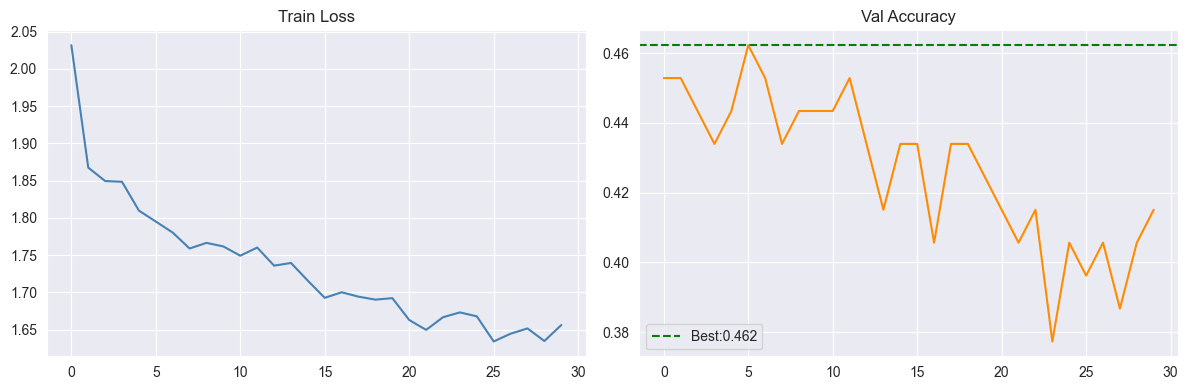

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, color='steelblue'); axes[0].set_title('Train Loss')
axes[1].plot(val_accs, color='darkorange')
axes[1].axhline(best_val_acc, color='green', ls='--', label=f'Best:{best_val_acc:.3f}')
axes[1].set_title('Val Accuracy'); axes[1].legend()
plt.tight_layout()
plt.savefig('notebooks/Laslo/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Embeddings BERT pentru vocabularul de 200 cuvinte
CLS token (`bert-base-uncased`), shape (200, 768).

In [13]:
from transformers import BertTokenizer, BertModel

tokenizer  = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()
bert_embeddings = np.zeros((len(vocab_list), 768), dtype=np.float32)
with torch.no_grad():
    for i, word in enumerate(vocab_list):
        inp = tokenizer(word, return_tensors='pt').to(device)
        out = bert_model(**inp)
        bert_embeddings[i] = out.last_hidden_state[:,0,:].squeeze().cpu().numpy()
print('BERT embeddings shape:', bert_embeddings.shape)
np.save('app/models/bert_embeddings.npy', bert_embeddings)
print('Salvat: app/models/bert_embeddings.npy')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\alexl\School\AI\eeg_ai_project\EEG-text\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alexl\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT embeddings shape: (200, 768)
Salvat: app/models/bert_embeddings.npy


## 7. Proiectie liniara EEG (128) -> BERT (768)
Loss: MSE pe embeddings normalizate L2.

In [14]:
model.eval()
model.load_state_dict(torch.load('app/models/eegnet_model.pt', map_location=device))

def extract_eeg_emb(X_np, bs=32):
    embs = []
    Xt = torch.tensor(X_np[:,np.newaxis,:,:], dtype=torch.float32)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            embs.append(model(Xt[i:i+bs].to(device), return_embedding=True).cpu().numpy())
    return np.vstack(embs)

eeg_emb_train = extract_eeg_emb(X_train)
eeg_emb_val   = extract_eeg_emb(X_val)
eeg_emb_test  = extract_eeg_emb(X_test)
print(f'EEG emb: train={eeg_emb_train.shape}, val={eeg_emb_val.shape}, test={eeg_emb_test.shape}')


EEG emb: train=(922, 128), val=(106, 128), test=(108, 128)


In [15]:
word2bertidx = {w: i for i, w in enumerate(vocab_list)}

def get_bert_target(labels_arr):
    return bert_embeddings[np.array([word2bertidx[l] for l in labels_arr])]

proj     = nn.Linear(128, 768).to(device)
proj_opt = torch.optim.Adam(proj.parameters(), lr=1e-3)
mse_fn   = nn.MSELoss()

proj_loader = DataLoader(
    TensorDataset(torch.tensor(eeg_emb_train, dtype=torch.float32),
                  torch.tensor(get_bert_target(y[train_idx]), dtype=torch.float32)),
    batch_size=32, shuffle=True)
ev = torch.tensor(eeg_emb_val,             dtype=torch.float32)
bv = torch.tensor(get_bert_target(y[val_idx]), dtype=torch.float32)

best_pl = float('inf')
ptl, pvl = [], []

for epoch in range(50):
    proj.train(); tl = 0
    for xb, yb in proj_loader:
        xb, yb = xb.to(device), yb.to(device)
        proj_opt.zero_grad()
        p  = proj(xb)
        pn = p  / (p.norm(dim=1, keepdim=True)  + 1e-8)
        yn = yb / (yb.norm(dim=1, keepdim=True) + 1e-8)
        loss = mse_fn(pn, yn); loss.backward(); proj_opt.step()
        tl += loss.item()
    proj.eval()
    with torch.no_grad():
        pv  = proj(ev.to(device))
        pvn = pv / (pv.norm(dim=1, keepdim=True) + 1e-8)
        bvn = bv.to(device) / (bv.to(device).norm(dim=1, keepdim=True) + 1e-8)
        vl  = mse_fn(pvn, bvn).item()
    ptl.append(tl/len(proj_loader)); pvl.append(vl)
    if (epoch+1)%10==0:
        print(f'Ep {epoch+1}/50 | train:{ptl[-1]:.4f} | val:{vl:.4f}')
    if vl < best_pl:
        best_pl = vl
        torch.save(proj.state_dict(), 'app/models/linear_projection.pt')
        print(f'  -> Proiectie salvata (val={vl:.4f})')
print('Salvat: app/models/linear_projection.pt')


  -> Proiectie salvata (val=0.0011)
  -> Proiectie salvata (val=0.0004)
  -> Proiectie salvata (val=0.0003)
  -> Proiectie salvata (val=0.0002)
  -> Proiectie salvata (val=0.0002)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
Ep 10/50 | train:0.0001 | val:0.0001
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
Ep 20/50 | train:0.0001 | val:0.0001
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
Ep 30/50 | train:0.0001 | val:0.0001
  -> Proiectie salvata (val=0.0001)
  -> Proiectie salvata (val=0.0001)
Ep 40/50 | train:0.0001 | val:0.0001
Ep 50/50 | train:0.0001 | val:0.0001
Salvat: app/models/line

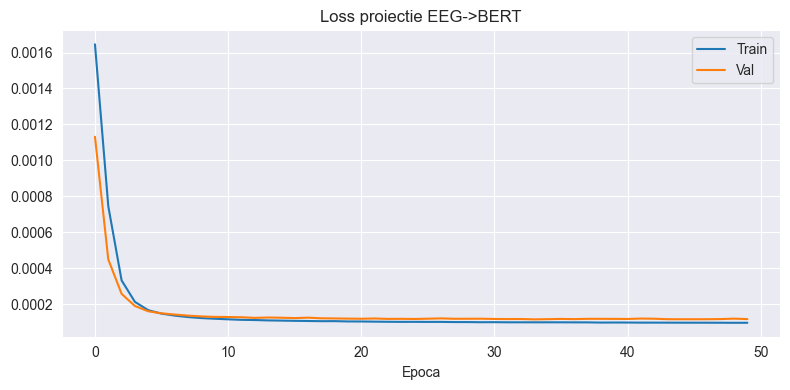

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(ptl, label='Train'); plt.plot(pvl, label='Val')
plt.title('Loss proiectie EEG->BERT'); plt.xlabel('Epoca'); plt.legend()
plt.tight_layout()
plt.savefig('notebooks/Laslo/projection_loss.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Evaluare Retrieval pe Test Set
Tinte: Top-1 > 10%, Top-5 > 30%, Cosine > 0.25

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

model.load_state_dict(torch.load('app/models/eegnet_model.pt', map_location=device))
proj.load_state_dict(torch.load('app/models/linear_projection.pt', map_location=device))
bert_emb_loaded = np.load('app/models/bert_embeddings.npy')
model.eval(); proj.eval()

eeg_emb_test = extract_eeg_emb(X_test)
with torch.no_grad():
    projected = proj(torch.tensor(eeg_emb_test, dtype=torch.float32).to(device)).cpu().numpy()

sims = cosine_similarity(projected, bert_emb_loaded)
top5 = np.argsort(sims, axis=1)[:,-5:][:,::-1]
test_labels = y[test_idx]
total = len(test_labels)
t1  = sum(top5[i,0]==word2bertidx[test_labels[i]] for i in range(total))
t5  = sum(word2bertidx[test_labels[i]] in top5[i] for i in range(total))
mc  = sims[np.arange(total), [word2bertidx[l] for l in test_labels]].mean()

print('=== REZULTATE RETRIEVAL ===')
print(f'Top-1: {t1/total:.3f} ({t1}/{total})')
print(f'Top-5: {t5/total:.3f} ({t5}/{total})')
print(f'Cosine: {mc:.3f}')
print(f'Top-1>10%:{"OK" if t1/total>.10 else "NU"} | Top-5>30%:{"OK" if t5/total>.30 else "NU"} | Cos>0.25:{"OK" if mc>.25 else "NU"}')


=== REZULTATE RETRIEVAL ===
Top-1: 0.130 (14/108)
Top-5: 0.148 (16/108)
Cosine: 0.933
Top-1>10%:OK | Top-5>30%:NU | Cos>0.25:OK


In [18]:
print('=== EXEMPLE PREDICTII ===')
for i in range(min(10, total)):
    tw = test_labels[i]
    pw = [vocab_list[idx] for idx in top5[i]]
    print(f'[{"OK" if tw==pw[0] else "--"}] True:{tw:20s} Top5:{pw}')


=== EXEMPLE PREDICTII ===
[--] True:human                Top5:['story', 'family', 'many', 'series', 'now']
[--] True:times                Top5:['movie', 'movies', 'film', 'story', 'series']
[--] True:much                 Top5:['story', 'brother', 'now', 'many', 'name']
[OK] True:story                Top5:['story', 'academy', 'mother', 'name', 'movie']
[--] True:much                 Top5:['movies', 'movie', 'story', 'series', 'work']
[--] True:life                 Top5:['story', 'name', 'series', 'family', 'mother']
[--] True:human                Top5:['often', 'brother', 'many', 'like', 'story']
[OK] True:story                Top5:['story', 'work', 'name', 'mother', 'named']
[--] True:despite              Top5:['story', 'work', 'name', 'mother', 'brother']
[--] True:life                 Top5:['work', 'story', 'now', 'mother', 'name']


## 9. Vizualizare t-SNE: EEG proiectat vs. BERT

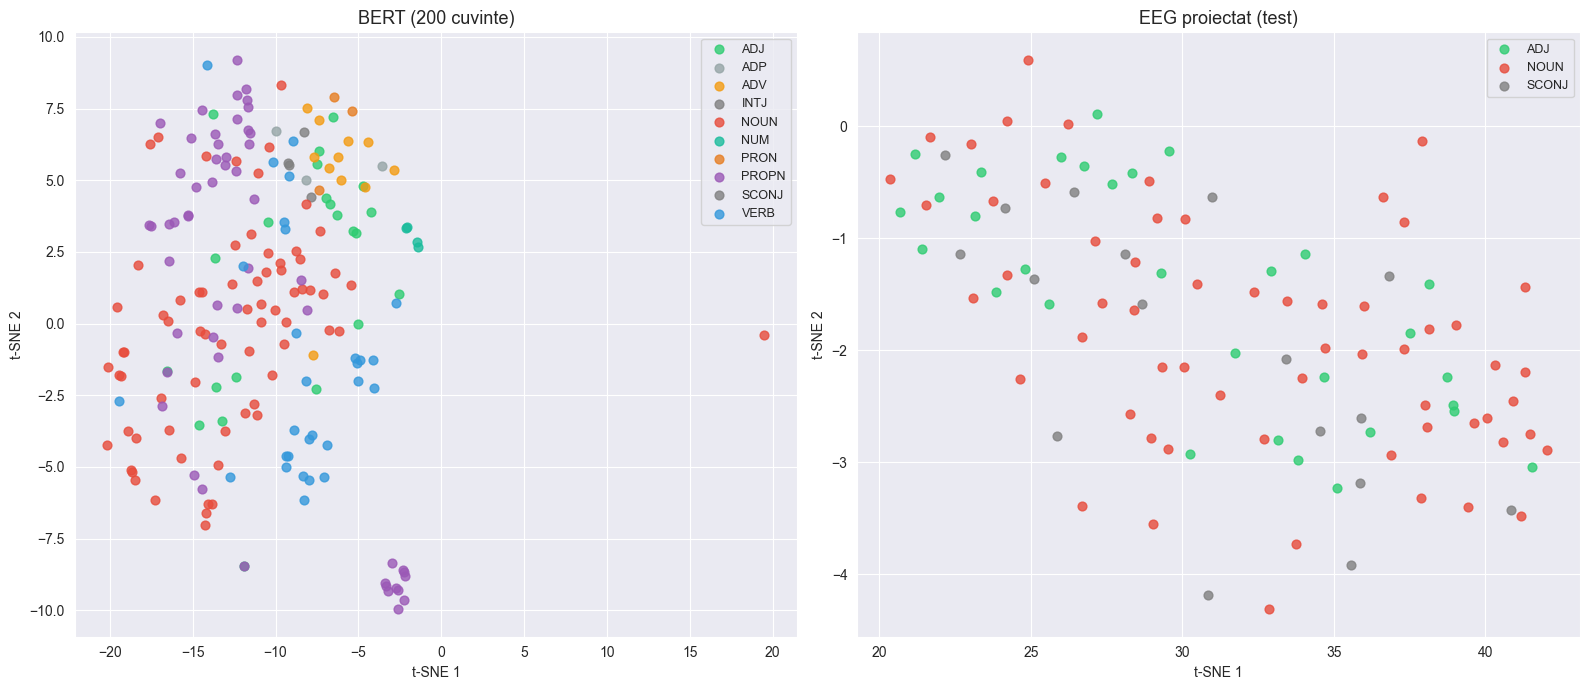

In [20]:
from sklearn.manifold import TSNE

all_v  = np.vstack([projected, bert_emb_loaded])
all_2d = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000, init='pca').fit_transform(all_v)
e2d = all_2d[:len(projected)]
b2d = all_2d[len(projected):]

pc = {'NOUN':'#e74c3c','VERB':'#3498db','ADJ':'#2ecc71','PROPN':'#9b59b6',
      'ADV':'#f39c12','NUM':'#1abc9c','ADP':'#95a5a6','PRON':'#e67e22'}
vpos = [pos_map.get(w,'NOUN') for w in vocab_list]
tpos = [pos_map.get(l,'NOUN') for l in test_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, vecs, poses, title in [
    (axes[0], b2d, vpos, 'BERT (200 cuvinte)'),
    (axes[1], e2d, tpos, 'EEG proiectat (test)')]:
    ax.set_title(title, fontsize=13)
    for pt in sorted(set(poses)):
        idx = [i for i,p in enumerate(poses) if p==pt]
        ax.scatter(vecs[idx,0], vecs[idx,1], c=pc.get(pt,'gray'), label=pt, alpha=0.8, s=40)
    ax.legend(fontsize=9); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('notebooks/Laslo/tsne_eeg_vs_bert.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Concluzii

**Ce functioneaza:**
- Pipeline end-to-end: EEG per-subiect (5 subiecti ZuCo1 SR) -> preprocesare -> EEGNet -> proiectie -> retrieval
- rawEEG shape (4, 105, 120) concatenat la (105, 480), pad la (105, 500)
- Proiectia 128->768 aliniaza spatiul EEG cu BERT

**Limitari:**
- 5 subiecti disponibili in repo
- EEG-Conformer ar putea fi mai bun decat EEGNet
- Contrastive learning (P2 - Magdas) ar imbunatati alinierea


In [21]:
files = ['app/models/eegnet_model.pt', 'app/models/linear_projection.pt',
         'app/models/bert_embeddings.npy', 'app/models/vocab_index.json']
print('=== VERIFICARE FINALA ===')
all_ok = True
for fp in files:
    ex = os.path.exists(fp)
    sz = f'{os.path.getsize(fp)/1024:.0f}KB' if ex else 'LIPSA'
    print(f'{"OK" if ex else "XX"} {fp:45s} {sz}')
    all_ok = all_ok and ex
if os.path.exists('app/models/bert_embeddings.npy'):
    emb = np.load('app/models/bert_embeddings.npy')
    print(f'   bert_embeddings shape: {emb.shape}')
print()
print('GATA - poti face PR!' if all_ok else 'ATENTIE: fisiere lipsa!')
print('Anunta-l pe Lupse sa seteze USE_MOCK=False in app/config.py')


=== VERIFICARE FINALA ===
OK app/models/eegnet_model.pt                    144KB
OK app/models/linear_projection.pt               389KB
OK app/models/bert_embeddings.npy                600KB
OK app/models/vocab_index.json                   4KB
   bert_embeddings shape: (200, 768)

GATA - poti face PR!
Anunta-l pe Lupse sa seteze USE_MOCK=False in app/config.py
